In [1]:
!pip install chromadb sentence-transformers torchvision torch pillow koreanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 12.3 MB/s eta 0:0

In [2]:
# vecdb04 응용
# VectorDB에 이미지 자료를 I/O
# 이미지 벡터화 처리는 Resnet 모델 사용
# 이미지 -> 벡터DB -> 저장 -> 검색
import os
import torch
from torchvision import transforms
from PIL import Image
from chromadb import PersistentClient
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import koreanize_matplotlib
from google.colab import files

# 이미지 업로드
uploaded = files.upload()

Saving banana.jpg to banana.jpg
Saving apple.jpg to apple.jpg
Saving peach.jpeg to peach.jpeg


In [5]:
# 이미지 벡터화(resnet18를 이용한 임베딩)
model = resnet18(weights='ResNet18_Weights.DEFAULT')    # 이미 학습이 끝난 모델
model.eval()    # 모델을 평가 모드로 전환. 훈련이 아니라 추론처럼 동작함
model = torch.nn.Sequential(*(list(model.children()))[:-1])

def image_to_vectorFunc(img_path):
  image = Image.open(img_path).convert('RGB')
  transform = transforms.Compose([
      transforms.Resize((224, 224)),    # Resnet18은 입력 이미지 크기 (3, 224, 224)를 원함
      transforms.ToTensor(),    # PIL.image를 torch.tensor로 변환
  ])
  tensor = transform(image).unsqueeze(0)    # 모델에 넣기 위해 batch 차원 추가. 앞에 +1 (unsqueeze는 차원 추가)

  with torch.no_grad():    # 역전파 계산을 끄고, 추론만 하겠다는 의미 (메모리 절약, 속도 증가)
    vec = model(tensor).squeeze().numpy()    # (512, ) 모든 크기의 1인 차원 제거
    # vec의 결과는 (1, 512, 1, 1) -> (512, )
  print(f"{img_path} -> 벡터(앞 10개) : {vec[:10]}")
  return vec.tolist()

client = PersistentClient("./image_chroma2")
collection = client.get_or_create_collection("images")

# 이미지 경로
image_files = ['apple.jpg','banana.jpg','peach.jpeg']
ids = [f"img{i}" for i in range(len(image_files))]
print(f"dis : {ids}")

# 벡터에 저장
for img_id, img_path in zip(ids, image_files):
  if not os.path.exists(img_path):
    print(f"파일 없음 : {img_path}")
    continue
  vec = image_to_vectorFunc(img_path)
  collection.add(
      embeddings=[vec],
      documents=[img_path],
      ids=[img_id],
      metadatas=[{"filename": img_path}]
  )

dis : ['img0', 'img1', 'img2']
apple.jpg -> 벡터(앞 10개) : [0.47947806 0.72125846 0.29288873 0.4093892  1.1582918  0.8449188
 0.22878729 1.3747462  0.94831544 0.8256881 ]
banana.jpg -> 벡터(앞 10개) : [1.3607993  0.00462919 0.17135125 2.5105228  0.29098478 3.3166971
 0.         0.02192617 0.03076949 1.0502701 ]
peach.jpeg -> 벡터(앞 10개) : [0.4146816  0.17171814 0.16761515 2.369082   1.6573105  0.4055574
 0.5105393  1.6036643  0.59981316 0.8076444 ]


id=img2
documents :  ['peach.jpeg']
metadatas :  [{'filename': 'peach.jpeg'}]
embeddings :  [0.41468161 0.17171814 0.16761515 2.36908197 1.65731049 0.40555739
 0.51053929 1.60366428 0.59981316 0.80764443]

apple.jpg -> 벡터(앞 10개) : [0.47947806 0.72125846 0.29288873 0.4093892  1.1582918  0.8449188
 0.22878729 1.3747462  0.94831544 0.8256881 ]
검색 이미지 : apple.jpg
유사 이미지
 - 파일명 : apple.jpg (유사도 거리:0.0000)
 - 파일명 : peach.jpeg (유사도 거리:185.0990)
 - 파일명 : banana.jpg (유사도 거리:529.7032)


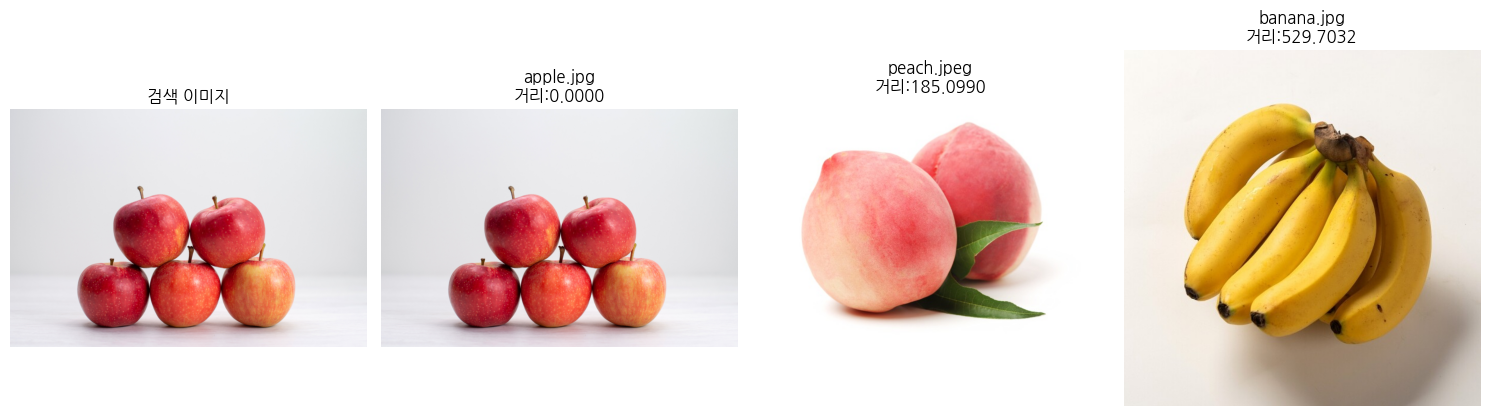

In [13]:
# 저장된 벡터 일부 출력
record = collection.get(ids=['img2'], include=['embeddings','documents','metadatas'])
if record is None:
  print("record is None")
else:
  print('id=img2')
  print('documents : ', record['documents'])
  print('metadatas : ', record['metadatas'])
  print('embeddings : ', record['embeddings'][0][:10])

print()

# 검색 이미지 설명
query_image_path = 'apple.jpg'

if not os.path.exists(query_image_path):
  print(f"파일 없음 : {query_image_path}")
else:
  query_vec = image_to_vectorFunc(query_image_path)
  results = collection.query(
      query_embeddings=[query_vec],
      n_results=3,
      include=["documents", "metadatas", "distances"])
  print(f"검색 이미지 : {query_image_path}")
  print("유사 이미지")
  for doc, meta, dist in zip(results['documents'][0], results['metadatas'][0], results['distances'][0]):
    print(f" - 파일명 : {meta['filename']} (유사도 거리:{dist:.4f})")

  # 이미지 시각화
  def show_similar_images(query_path, result_path, distances):
    fig, axes = plt.subplots(1, len(result_path) + 1, figsize=(15,5))

    # 검색 이미지
    query_img = Image.open(query_path)
    axes[0].imshow(query_img)
    axes[0].set_title('검색 이미지')
    axes[0].axis('off')

    # 결과 이미지들
    for i, (path, dist) in enumerate(zip(result_path, distances), start=1):
      if not os.path.exists(path): continue
      sim_img = Image.open(path)
      axes[i].imshow(sim_img)
      axes[i].set_title(f'{os.path.basename(path)}\n거리:{dist:.4f}')
      axes[i].axis('off')

    plt.tight_layout()
    plt.show()

  result_paths = results['documents'][0]
  distances = results['distances'][0]
  show_similar_images(query_image_path, result_paths, distances)
  # end of if